In [25]:
import numpy as np
from astropy.table import Table
import pylab as pl
from astropy import units as u
basepath = '/orange/adamginsburg/jwst/brick/'

In [14]:
ls -lh $basepath/catalogs/crowdsource_nsky0_merged-reproject_photometry_tables_merged_20231003.fits $basepath//catalogs/crowdsource_nsky0_merged_indivexp_photometry_tables_merged_qualcuts_oksep2221.fits

-rw-r--r-- 1 adamginsburg adamginsburg 7.0G Aug  5  2024 /orange/adamginsburg/jwst/brick///catalogs/crowdsource_nsky0_merged_indivexp_photometry_tables_merged_qualcuts_oksep2221.fits
-rw-r--r-- 1 adamginsburg adamginsburg 468M Oct  4  2023 /orange/adamginsburg/jwst/brick//catalogs/crowdsource_nsky0_merged-reproject_photometry_tables_merged_20231003.fits


In [15]:
basetable_merged_reproject = Table.read(f'{basepath}/catalogs/crowdsource_nsky0_merged-reproject_photometry_tables_merged_20231003.fits')
basetable_basic_merged1182 = Table.read(f'{basepath}/catalogs/basic_merged_indivexp_photometry_tables_merged_nirspeccand.fits')

In [18]:
idx, sidx, sep, sep3d = basetable_merged_reproject['skycoord_ref'].search_around_sky(basetable_basic_merged1182['skycoord_ref'], 0.05*u.arcsec)
len(idx)

12155

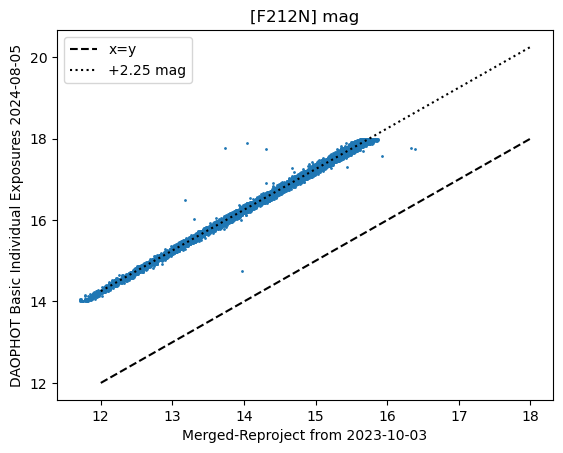

In [64]:
pl.scatter(basetable_merged_reproject['mag_ab_f212n'][sidx], basetable_basic_merged1182['mag_ab_f212n'][idx], s=1)
diff = basetable_merged_reproject['mag_ab_f212n'][sidx] - basetable_basic_merged1182['mag_ab_f212n'][idx]
diff = np.array(diff[diff == diff])
offset = -np.nanmedian(diff)
pl.plot([12, 18], [12, 18], 'k--', label='x=y')
pl.plot([12, 18], np.array([12, 18])+offset, 'k:', label=f'+{offset:0.2f} mag')
pl.xlabel("Merged-Reproject from 2023-10-03")
pl.ylabel("DAOPHOT Basic Individual Exposures 2024-08-05")
pl.legend(loc='best')
pl.title("[F212N] mag");

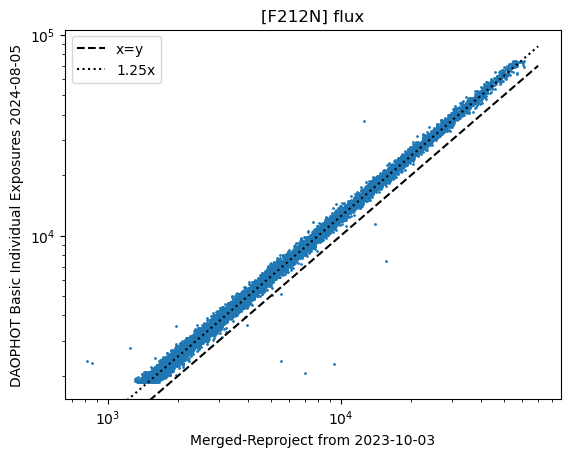

In [47]:
pl.scatter(basetable_merged_reproject['flux_f212n'][sidx], basetable_basic_merged1182['flux_f212n'][idx], s=1)
pl.loglog([0, 7e4], [0, 7e4], 'k--', label='x=y')
pl.loglog([0, 7e4], np.array([0, 7e4])*1.25, 'k:', label='1.25x')
pl.xlabel("Merged-Reproject from 2023-10-03")
pl.ylabel("DAOPHOT Basic Individual Exposures 2024-08-05")
pl.legend()
pl.title("[F212N] flux");

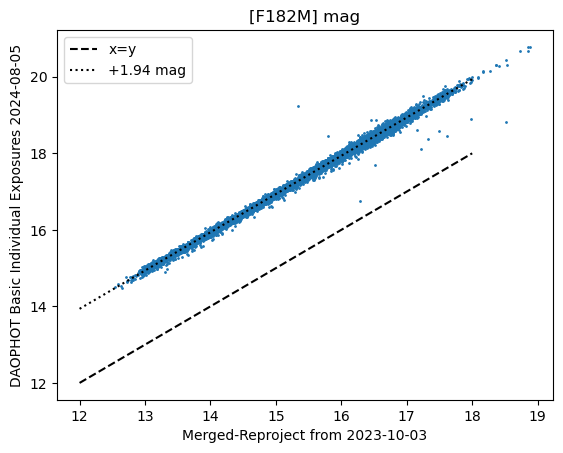

In [61]:
pl.scatter(basetable_merged_reproject['mag_ab_f182m'][sidx], basetable_basic_merged1182['mag_ab_f182m'][idx], s=1)
diff = basetable_merged_reproject['mag_ab_f182m'][sidx] - basetable_basic_merged1182['mag_ab_f182m'][idx]
diff = np.array(diff[diff == diff])
offset = -np.nanmedian(diff)
pl.plot([12, 18], [12, 18], 'k--', label='x=y')
pl.plot([12, 18], np.array([12, 18])+offset, 'k:', label=f'+{offset:0.2f} mag')
pl.xlabel("Merged-Reproject from 2023-10-03")
pl.ylabel("DAOPHOT Basic Individual Exposures 2024-08-05")
pl.legend()
pl.title("[F182M] mag");

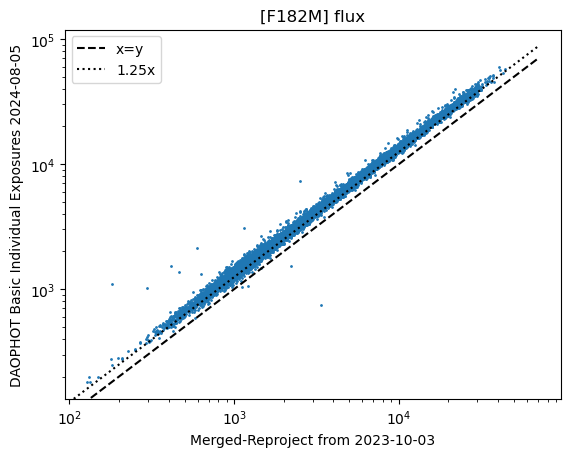

In [49]:
pl.scatter(basetable_merged_reproject['flux_f182m'][sidx], basetable_basic_merged1182['flux_f182m'][idx], s=1)
pl.loglog([0, 7e4], [0, 7e4], 'k--', label='x=y')
pl.loglog([0, 7e4], np.array([0, 7e4])*1.25, 'k:', label='1.25x')
pl.xlabel("Merged-Reproject from 2023-10-03")
pl.ylabel("DAOPHOT Basic Individual Exposures 2024-08-05")
pl.legend()
pl.title("[F182M] flux");

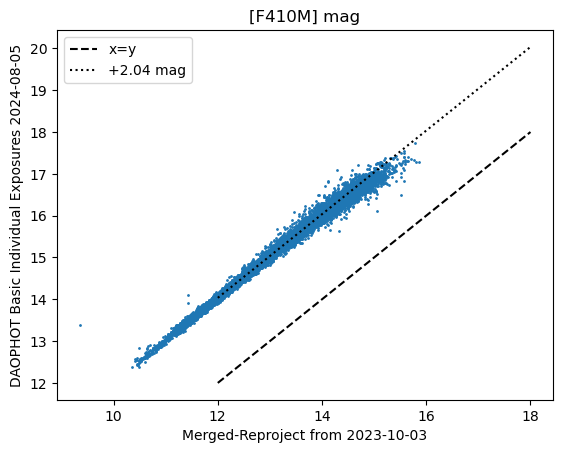

In [102]:
pl.scatter(basetable_merged_reproject['mag_ab_f410m'][sidx], basetable_basic_merged1182['mag_ab_f410m'][idx], s=1)
diff = basetable_merged_reproject['mag_ab_f410m'][sidx] - basetable_basic_merged1182['mag_ab_f410m'][idx]
diff = np.array(diff[diff == diff])
offset = -np.nanmedian(diff)
pl.plot([12, 18], [12, 18], 'k--', label='x=y')
pl.plot([12, 18], np.array([12, 18])+offset, 'k:', label=f'+{offset:0.2f} mag')
pl.xlabel("Merged-Reproject from 2023-10-03")
pl.ylabel("DAOPHOT Basic Individual Exposures 2024-08-05")
pl.legend()
pl.title("[F410M] mag");

## Did we correct the zero-point problem?

I apparently didn't document it, but I had originally used the wrong zeropoints by using `.to(u.ABmag)` instead of adopting the real zero point conversion

In [100]:
from astroquery.svo_fps import SvoFps
jfilts = SvoFps.get_filter_list('JWST')
jfilts.add_index('filterID')
abconv = (1*u.Jy).to(u.ABmag)
filtconv182 = -2.5*np.log10(1/jfilts.loc['JWST/NIRCam.F182M']['ZeroPoint']) - abconv.value
filtconv212 = -2.5*np.log10(1/jfilts.loc['JWST/NIRCam.F212N']['ZeroPoint']) - abconv.value
filtconv410 = -2.5*np.log10(1/jfilts.loc['JWST/NIRCam.F410M']['ZeroPoint']) - abconv.value
zeropoint_offset_182_212 = filtconv182-filtconv212
filtconv182, filtconv212, zeropoint_offset_182_212, filtconv410, filtconv212-filtconv410

(-1.582931092814813,
 -1.8270113541527708,
 0.2440802613379578,
 -3.100931445988974,
 1.273920091836203)

From above, the difference in the crowdsource

In [65]:
2.25 - 1.94

0.31000000000000005

In [67]:
import dust_extinction
from dust_extinction.averages import RRP89_MWGC, CT06_MWGC, F11_MWGC, G21_MWAvg

In [66]:
0.31 / (CT06_MWGC()(1.82*u.um) - CT06_MWGC()(2.12*u.um))

9.716993684895833

In [81]:
print(f"{'name':15s} {'E(1.82-2.12)':>12s} {'A_V(1 mag)':>12s}")
for ex in (RRP89_MWGC, CT06_MWGC, F11_MWGC, G21_MWAvg):
    ex = ex()
    print(f"{ex.__class__.__name__:15s} {ex(1.82*u.um) - ex(2.12*u.um):12.2f} {1/(ex(1.82*u.um) - ex(2.12*u.um)):12.2f}")

name            E(1.82-2.12)   A_V(1 mag)
RRP89_MWGC              0.03        34.92
CT06_MWGC               0.03        31.35
F11_MWGC                0.06        17.56
G21_MWAvg               0.03        32.80


Nogueras-Lara 2021 report that H-K for the brick starts at about 1.5

In [91]:
paranal = SvoFps.get_filter_list('Paranal')
paranal.add_index('filterID')
paranal.loc['Paranal/VISTA.H']['WavelengthEff'], paranal.loc['Paranal/VISTA.Ks']['WavelengthEff']

(16347.442813614, 21435.271592899)

In [97]:
e_HK = CT06_MWGC()(paranal.loc['Paranal/VISTA.H']['WavelengthEff']*u.AA) - CT06_MWGC()(paranal.loc['Paranal/VISTA.Ks']['WavelengthEff']*u.AA)
e_182 =  CT06_MWGC()(jfilts.loc['JWST/NIRCam.F182M']['WavelengthEff']*u.AA) - CT06_MWGC()(jfilts.loc['JWST/NIRCam.F212N']['WavelengthEff']*u.AA)
e_182/e_HK

0.4579730314706651

In [98]:
1.5 * e_182/e_HK

0.6869595472059976

In [99]:
1.5 / e_HK

23.371679394181573